In [ ]:
import random

# Set a global seed for Python's random module for reproducibility
random_seed = 42
random.seed(random_seed)

print(f"Global random seed set to: {random_seed}")

Global random seed set to: 42


In [ ]:
!pip install seaborn plotly transformer_lens
!pip uninstall -y torchaudio

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.3 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=686cfc1edf5c11a7a44a486ea072c065b1e75f5b28cf5df0adb5ff6bb3f91502
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


In [ ]:
import json
import numpy as np
import torch
from google.colab import drive
from huggingface_hub import login
from transformer_lens import HookedTransformer

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
FILE_PATH = "/content/drive/MyDrive/Projects/PRISM/data/CombSub_dataset.json"

In [ ]:
with open(FILE_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

In [ ]:
rule_cats = dataset['metadata']['rule_types']

In [ ]:
rule_cats

['formatting+language',
 'style+code',
 'persona+restriction',
 'structure+sentiment']

In [ ]:
trainset = dataset['train']
trainset[0]

{'id': 'train_imperative_000',
 'split': 'train',
 'grammar_type': 'imperative',
 'label': 1,
 'label_name': 'binding_active',
 'context': 'What is the capital of France?',
 'context_type': 'neutral_question',
 'rule': 'Answer in 5 words in French.',
 'assembled_input': 'What is the capital of France? Answer in 5 words in French.',
 'rule_type': 'formatting+language',
 'full_rule': 'Answer in 5 words in French.',
 'domain_a': 'Answer in 5 words.',
 'domain_b': 'Answer in French.',
 'semantic_baseline': 'A response of 5 words in French is a common formatting choice.',
 'assembled_full_rule': 'What is the capital of France? Answer in 5 words in French.',
 'assembled_domain_a': 'What is the capital of France? Answer in 5 words.',
 'assembled_domain_b': 'What is the capital of France? Answer in French.',
 'assembled_semantic_baseline': 'What is the capital of France? A response of 5 words in French is a common formatting choice.'}

In [ ]:
rule_dict = {r: [i for i in trainset if i['rule_type'] == r] for r in rule_cats}

In [ ]:
rule_dict.keys()

dict_keys(['formatting+language', 'style+code', 'persona+restriction', 'structure+sentiment'])

In [ ]:
# HF login for Llamas
login()


device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained_no_processing(
    "meta-llama/Llama-3.2-1B-Instruct",
    device=device,
    torch_dtype=torch.float16,
)

n_layers = model.cfg.n_layers
d_model = model.cfg.d_model

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer


In [ ]:
max_new_tokens = 60
temperature = 0.
model.eval()
hook_attn = "hook_attn_out"
hook_mlp = "hook_mlp_out"

In [ ]:
%%time
prompt_dict = {}
for rule_cat in rule_dict.keys():
  for idx in range(8):
    inp = rule_dict[rule_cat][idx]['assembled_full_rule']
    print(inp)
    input_tokens = model.to_tokens(inp)

    output_tokens = model.generate(
        input_tokens,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        verbose=False
    )
    full_output_str = model.to_string(output_tokens[0])
    print(full_output_str)
    print('#################################################')
    generated_answer = full_output_str[len(inp):].strip()
    prompt_dict[inp] = generated_answer

What is the capital of France? Answer in 5 words in French.
<|begin_of_text|>What is the capital of France? Answer in 5 words in French. La Ville de Paris.<|eot_id|>
#################################################
Who wrote Romeo and Juliet? Answer in 3 sentences in German.


KeyboardInterrupt: 

In [ ]:
for prompt, answer in prompt_dict.items():
  print(prompt)
  print(answer)
  print('#################################################')

What is the capital of France? Answer in 5 words in French.
words in French. La Ville de Paris.<|eot_id|>
#################################################
Who wrote Romeo and Juliet? Answer in 3 sentences in German.
tences in German. Wer schrieb Romeo und Julia? Antwort: William Shakespeare. 

Romeo und Julia sind eine Tragödie von William Shakespeare, die 1595 in England urteilt wurde. Sie handelt von den Verlobten, die sich in einem tragischen Konflikt be
#################################################
What is the speed of light? Answer in bullet points in Spanish.
oints in Spanish. La velocidad del luz es de 299.792 kilómetros por segundo.

• La velocidad del luz es una constante física fundamental en la física.
• Se utiliza para medir distancias y velocidades en diferentes campos.
• La velocidad del luz es igual a la velocidad de la
#################################################
How many continents are there? Answer in exactly 10 words in Italian.
words in Italian. Quante con

In [ ]:
torch.manual_seed(42)

### What heads are attending to the RB most?

Tracking the attention towards the rules vs non-rules and possibly even specific tokens.
Assuming the tokens manually for now for the specific set of given rules.

In [ ]:
# Format: ("Operational Prompt / Active Mode (X+)", "Declarative Prompt / Passive Mode (X-)")
contrastive_dataset = [
    # =========================================================================
    # GROUP 1: THE IMPERATIVE MOOD (30 Pairs)
    # Direct command syntax: [Verb] + [Object]
    # =========================================================================
    ("Translate into French.", "This text is written in French."),
    ("Translate into Spanish.", "This text is written in Spanish."),
    ("Translate into German.", "This text is written in German."),
    ("Translate into Italian.", "This text is written in Italian."),
    ("Translate into Portuguese.", "This text is written in Portuguese."),
    ("Translate into Japanese.", "This text is written in Japanese."),
    ("Translate into Chinese.", "This text is written in Chinese."),
    ("Translate into Russian.", "This text is written in Russian."),
    ("Translate into Arabic.", "This text is written in Arabic."),
    ("Translate into Hindi.", "This text is written in Hindi."),
    ("Write using bullet points.", "This is written using bullet points."),
    ("Write a numbered list.", "This is a numbered list."),
    ("Write in JSON format.", "This is in JSON format."),
    ("Write in XML format.", "This is in XML format."),
    ("Write in Markdown format.", "This is in Markdown format."),
    ("Write a Markdown table.", "This is a Markdown table."),
    ("Write using CSV format.", "This is in CSV format."),
    ("Write a plain text summary.", "This is a plain text summary."),
    ("Write inside an HTML block.", "This is inside an HTML block."),
    ("Write in capital letters.", "This is written in capital letters."),
    ("Write using lowercase.", "This is written using lowercase."),
    ("Write using bold font.", "This is written using bold font."),
    ("Write in a formal tone.", "This is written in a formal tone."),
    ("Write a humorous response.", "This is a humorous response."),
    ("Write a poetic description.", "This is a poetic description."),
    ("Write a technical explanation.", "This is a technical explanation."),
    ("Write a Python function.", "This is a Python function."),
    ("Write a JavaScript loop.", "This is a JavaScript loop."),
    ("Write a CSS rule.", "This is a CSS rule."),
    ("Write a SQL query.", "This is a SQL query."),

    # =========================================================================
    # GROUP 2: MODAL OBLIGATION (30 Pairs)
    # Deontic syntax: "You must / You should / You need to" + [Verb]
    # =========================================================================
    ("You must translate into French.", "This text is written in French."),
    ("You must translate into Spanish.", "This text is written in Spanish."),
    ("You must translate into German.", "This text is written in German."),
    ("You should translate into Italian.", "This text is written in Italian."),
    ("You should translate into Portuguese.", "This text is written in Portuguese."),
    ("You should translate into Japanese.", "This text is written in Japanese."),
    ("You need to translate into Chinese.", "This text is written in Chinese."),
    ("You need to translate into Russian.", "This text is written in Russian."),
    ("You need to translate into Arabic.", "This text is written in Arabic."),
    ("You need to translate into Hindi.", "This text is written in Hindi."),
    ("You must write using bullet points.", "This is written using bullet points."),
    ("You must write a numbered list.", "This is a numbered list."),
    ("You must write in JSON format.", "This is in JSON format."),
    ("You should write in XML format.", "This is in XML format."),
    ("You should write in Markdown format.", "This is in Markdown format."),
    ("You should write a Markdown table.", "This is a Markdown table."),
    ("You need to write using CSV format.", "This is in CSV format."),
    ("You need to write a plain text summary.", "This is a plain text summary."),
    ("You need to write inside an HTML block.", "This is inside an HTML block."),
    ("You must write in capital letters.", "This is written in capital letters."),
    ("You must write using lowercase.", "This is written using lowercase."),
    ("You must write using bold font.", "This is written using bold font."),
    ("You should write in a formal tone.", "This is written in a formal tone."),
    ("You should write a humorous response.", "This is a humorous response."),
    ("You should write a poetic description.", "This is a poetic description."),
    ("You need to write a technical explanation.", "This is a technical explanation."),
    ("You need to write a Python function.", "This is a Python function."),
    ("You need to write a JavaScript loop.", "This is a JavaScript loop."),
    ("You need to write a CSS rule.", "This is a CSS rule."),
    ("You need to write a SQL query.", "This is a SQL query."),

    # =========================================================================
    # GROUP 3: POLITE INTERROGATIVE / ASKED NICELY (30 Pairs)
    # Question syntax: "Could you please / Would you be able to" + [Verb]
    # =========================================================================
    ("Could you please translate into French?", "This text is written in French."),
    ("Could you please translate into Spanish?", "This text is written in Spanish."),
    ("Could you please translate into German?", "This text is written in German."),
    ("Could you please translate into Italian?", "This text is written in Italian."),
    ("Would you be able to translate into Portuguese?", "This text is written in Portuguese."),
    ("Would you be able to translate into Japanese?", "This text is written in Japanese."),
    ("Would you be able to translate into Chinese?", "This text is written in Chinese."),
    ("Can you please translate into Russian?", "This text is written in Russian."),
    ("Can you please translate into Arabic?", "This text is written in Arabic."),
    ("Can you please translate into Hindi?", "This text is written in Hindi."),
    ("Could you please write using bullet points?", "This is written using bullet points."),
    ("Could you please write a numbered list?", "This is a numbered list."),
    ("Could you please write in JSON format?", "This is in JSON format."),
    ("Would you be able to write in XML format?", "This is in XML format."),
    ("Would you be able to write in Markdown format?", "This is in Markdown format."),
    ("Would you be able to write a Markdown table?", "This is a Markdown table."),
    ("Can you please write using CSV format?", "This is in CSV format."),
    ("Can you please write a plain text summary?", "This is a plain text summary."),
    ("Can you please write inside an HTML block?", "This is inside an HTML block."),
    ("Could you please write in capital letters?", "This is written in capital letters."),
    ("Could you please write using lowercase?", "This is written using lowercase."),
    ("Could you please write using bold font?", "This is written using bold font."),
    ("Would you be able to write in a formal tone?", "This is written in a formal tone."),
    ("Would you be able to write a humorous response?", "This is a humorous response."),
    ("Would you be able to write a poetic description?", "This is a poetic description."),
    ("Can you please write a technical explanation?", "This is a technical explanation."),
    ("Can you please write a Python function?", "This is a Python function."),
    ("Can you please write a JavaScript loop?", "This is a JavaScript loop."),
    ("Can you please write a CSS rule?", "This is a CSS rule."),
    ("Can you please write a SQL query?", "This is a SQL query."),

    # =========================================================================
    # GROUP 4: POLITE IMPERATIVE / WITH "PLEASE" (30 Pairs)
    # Softened direct syntax: "Please," + [Verb]
    # =========================================================================
    ("Please, translate into French.", "This text is written in French."),
    ("Please, translate into Spanish.", "This text is written in Spanish."),
    ("Please, translate into German.", "This text is written in German."),
    ("Please, translate into Italian.", "This text is written in Italian."),
    ("Please, translate into Portuguese.", "This text is written in Portuguese."),
    ("Please, translate into Japanese.", "This text is written in Japanese."),
    ("Please, translate into Chinese.", "This text is written in Chinese."),
    ("Please, translate into Russian.", "This text is written in Russian."),
    ("Please, translate into Arabic.", "This text is written in Arabic."),
    ("Please, translate into Hindi.", "This text is written in Hindi."),
    ("Please, write using bullet points.", "This is written using bullet points."),
    ("Please, write a numbered list.", "This is a numbered list."),
    ("Please, write in JSON format.", "This is in JSON format."),
    ("Please, write in XML format.", "This is in XML format."),
    ("Please, write in Markdown format.", "This is in Markdown format."),
    ("Please, write a Markdown table.", "This is a Markdown table."),
    ("Please, write using CSV format.", "This is in CSV format."),
    ("Please, write a plain text summary.", "This is a plain text summary."),
    ("Please, write inside an HTML block.", "This is inside an HTML block."),
    ("Please, write in capital letters.", "This is written in capital letters."),
    ("Please, write using lowercase.", "This is written using lowercase."),
    ("Please, write using bold font.", "This is written using bold font."),
    ("Please, write in a formal tone.", "This is written in a formal tone."),
    ("Please, write a humorous response.", "This is a humorous response."),
    ("Please, write a poetic description.", "This is a poetic description."),
]

In [ ]:
from typing import Optional, List
import re
from dataclasses import dataclass
from typing import Optional

import torch
import transformer_lens
from transformers import AutoTokenizer

In [ ]:
@dataclass
class TargetTokenMatch:
    """Represents a single token that belongs to a target word occurrence."""
    token_idx: int          # position in the token sequence
    token_str: str          # the token string (may be a subword fragment)
    target_word: str        # the target word this token belongs to
    char_start: int         # character start of this token in the original string
    char_end: int           # character end of this token in the original string
    word_char_start: int    # character start of the full target word match
    word_char_end: int      # character end of the full target word match

In [ ]:
def find_target_word_spans(text: str, target_words: list[str]) -> list[tuple[int, int, str]]:
    """
    Find all character-level spans of target words in the text.
    Uses word-boundary matching to avoid partial hits.

    Returns list of (char_start, char_end, matched_word) tuples.
    """
    spans = []
    for word in target_words:
        pattern = r'\b' + re.escape(word) + r'\b'
        for match_ in re.finditer(pattern, text, flags=re.IGNORECASE):
            spans.append((match_.start(), match_.end(), word))

    # Sort by character position for clarity
    spans.sort(key=lambda x: x[0])
    return spans

In [ ]:
def match_target_tokens(
    text: str,
    target_words: List[str],
    tokenizer: AutoTokenizer,
    prepend_bos: bool = True,
) -> list[TargetTokenMatch]:
    """
    Given a text string and a list of target words, returns a list of
    TargetTokenMatch objects identifying exactly which token indices
    correspond to target word occurrences.

    Uses character-level offset mapping from HuggingFace tokenizer to
    avoid false subword matches.

    Args:
        text:           The input string (e.g. your assembled_input from dataset)
        target_words:   List of words/phrases to find (case-insensitive, word-boundary matched)
        tokenizer:      HuggingFace tokenizer corresponding to your TransformerLens model
        prepend_bos:    Whether TransformerLens prepends a BOS token (default True).
                        If True, all token indices are shifted by +1 to account for BOS.

    Returns:
        List of TargetTokenMatch, one per token that belongs to a target word.
        A multi-token target word (e.g. "you must" -> ["you", " must"]) produces
        multiple TargetTokenMatch entries, one per token.
    """
    # Step 1: find character spans of target words in raw text
    word_spans = find_target_word_spans(text, target_words)

    if not word_spans:
        return []

    # Step 2: tokenize with offset mapping
    # return_offsets_mapping gives us (char_start, char_end) per token
    encoding = tokenizer(
        text,
        return_offsets_mapping=True,
        add_special_tokens=False,  # we handle BOS separately via prepend_bos
    )

    token_ids = encoding["input_ids"]
    offset_mapping = encoding["offset_mapping"]  # list of (start, end) per token
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    # Step 3: for each token, check if its character span overlaps with any target word span
    bos_offset = 1 if prepend_bos else 0
    matches = []

    for tok_idx, (tok_str, (tok_start, tok_end)) in enumerate(zip(tokens, offset_mapping)):
        # Skip special tokens that the tokenizer marks with (0, 0) offsets
        if tok_start == 0 and tok_end == 0 and tok_idx > 0:
            continue

        for (word_start, word_end, word) in word_spans:
            # A token belongs to a target word if their character spans overlap
            # Overlap condition: token starts before word ends AND token ends after word starts
            if tok_start < word_end and tok_end > word_start:
                matches.append(TargetTokenMatch(
                    token_idx=tok_idx + bos_offset,
                    token_str=tok_str,
                    target_word=word,
                    char_start=tok_start,
                    char_end=tok_end,
                    word_char_start=word_start,
                    word_char_end=word_end,
                ))

    return matches

In [ ]:
def get_target_token_activations(
    text: str,
    target_words: list[str],
    tl_model: transformer_lens.HookedTransformer,
    hook_point: str = "hook_resid_post",
    layers: Optional[list[int]] = None,
    device: str = "cuda",
) -> dict:
    """Matches tokens to target rule words and extracts their activations."""
    tokenizer = tl_model.tokenizer

    # Find matched token positions
    matches = match_target_tokens(
        text=text,
        target_words=target_words,
        tokenizer=tokenizer,
        prepend_bos=True,
    )

    if not matches:
        return {"matches": [], "activations": {}, "token_indices": []}

    token_indices = [m.token_idx for m in matches]

    # Tokenize for TransformerLens (with BOS)
    tokens = tl_model.to_tokens(text, prepend_bos=True).to(device)

    # Determine which layers to extract
    n_layers = tl_model.cfg.n_layers
    if layers is None:
        layers = list(range(n_layers))

    # Build hook names
    hook_names = [f"blocks.{l}.{hook_point}" for l in layers]

    # Run forward pass with cache
    with torch.no_grad():
        _, cache = tl_model.run_with_cache(
            tokens,
            names_filter=lambda name: name in hook_names,
        )

    # Extract activations at target token positions
    activations = {}
    for l, hook_name in zip(layers, hook_names):
        # cache[hook_name] shape: (batch, seq_len, d_model)
        layer_acts = cache[hook_name][0]  # remove batch dim -> (seq_len, d_model)
        target_acts = layer_acts[token_indices]  # (n_matches, d_model)
        activations[l] = target_acts.cpu()

    return {
        "matches": matches,
        "activations": activations,
        "token_indices": token_indices,
    }

In [ ]:
def extract_mean_final_token_activations(
    model: HookedTransformer,
    texts: List[str],
    hook_name: str,
    layers: List[int] = list(range(n_layers))
) -> torch.Tensor:
    """
    Extracts the final token (-1) activations across multiple texts and layers,
    returning a single tensor averaged across the text inputs.
    A PyTorch tensor of shape (len(layers), d_model) containing the mean activations.
    """
    full_hook_names = [f"blocks.{l}.{hook_name}" for l in layers]

    accumulated_activations = {name: torch.zeros(model.cfg.d_model, dtype=torch.float32) for name in full_hook_names}
    valid_text_count = 0

    for text in texts:
        if not text.strip():
            continue
        # extract cache for given names
        _, cache = model.run_with_cache(
            text,
            names_filter=lambda name: name in full_hook_names
        )

        for name in full_hook_names:
          # extract the last token (the data is clean enough)
          final_token_vector = cache[name][0, -1, :].detach().cpu().to(torch.float32)
          accumulated_activations[name] += final_token_vector

        valid_text_count += 1

    if valid_text_count == 0:
        raise ValueError("No valid texts were processed. Check your text list.")

    # compute mean (enough for PoC for now)
    mean_layer_vectors = []
    for name in full_hook_names:
        mean_vector = accumulated_activations[name] / valid_text_count
        # Cast back to the model's native precision (e.g., float16)
        mean_layer_vectors.append(mean_vector.to(model.cfg.dtype))

    # output shape: (n_layers, d_model)
    final_activation_tensor = torch.stack(mean_layer_vectors, dim=0)

    return final_activation_tensor


In [ ]:
def extract_mean_final_token_head_output(
    model: HookedTransformer,
    texts: List[str],
    layers: List[int] = list(range(n_layers))
) -> torch.Tensor:
    """
    Extracts the mean output for each attention head across multiple texts and layers,
    for the final token. This specifically hooks the output *before* the final projection
    to d_model, allowing for per-head visualization.
    Returns a PyTorch tensor of shape (len(layers), n_heads) containing the mean activations.
    """
    hook_name_template = "blocks.{l}.attn.hook_z" # Output of attention heads before projection
    full_hook_names = [hook_name_template.format(l=l) for l in layers]

    accumulated_activations = {name: torch.zeros(model.cfg.n_heads, dtype=torch.float32) for name in full_hook_names}
    valid_text_count = 0

    for text in texts:
        if not text.strip(): # Skip empty texts
            continue

        # Run forward pass with cache
        _, cache = model.run_with_cache(
            text,
            names_filter=lambda name: name in full_hook_names
        )

        for name in full_hook_names:
            # cache[name] shape: (batch, seq_len, n_heads, d_head)
            # Take the final token (-1), average over d_head (dim=-1) to get (n_heads) per layer
            final_token_head_output = cache[name][0, -1, :, :].mean(dim=-1).detach().cpu().to(torch.float32)
            accumulated_activations[name] += final_token_head_output

        valid_text_count += 1

    if valid_text_count == 0:
        raise ValueError("No valid texts were processed. Check your text list.")

    mean_layer_head_outputs = []
    for name in full_hook_names:
        mean_vector = accumulated_activations[name] / valid_text_count
        mean_layer_head_outputs.append(mean_vector.to(model.cfg.dtype))

    # The final output tensor shape should be (n_layers, n_heads)
    final_activation_tensor = torch.stack(mean_layer_head_outputs, dim=0)

    return final_activation_tensor

In [ ]:
rules = [imp for imp, dec in contrastive_dataset]
non_rules = [dec for imp, dec in contrastive_dataset]

In [ ]:
# Calculate head activations using the new function
rules_acts_heads = extract_mean_final_token_head_output(
    model,
    rules,
    layers=list(range(n_layers))
)
non_rules_acts_heads = extract_mean_final_token_head_output(
    model,
    non_rules,
    layers=list(range(n_layers))
)
deltas_heads = rules_acts_heads - non_rules_acts_heads

In [ ]:
def plot_activation_heatmap(matrix, title, xlabel, ylabel):
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(18, 9))
    ax = sns.heatmap(
        matrix,
        cmap="viridis",
        xticklabels=[f"H{i}" for i in range(model.cfg.n_heads)],
        yticklabels=[f"L{i}" for i in range(model.cfg.n_layers)],
        cbar_kws={'label': 'Activation Value'}
    )

    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(xlabel, fontsize=12, labelpad=10)
    plt.ylabel(ylabel, fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

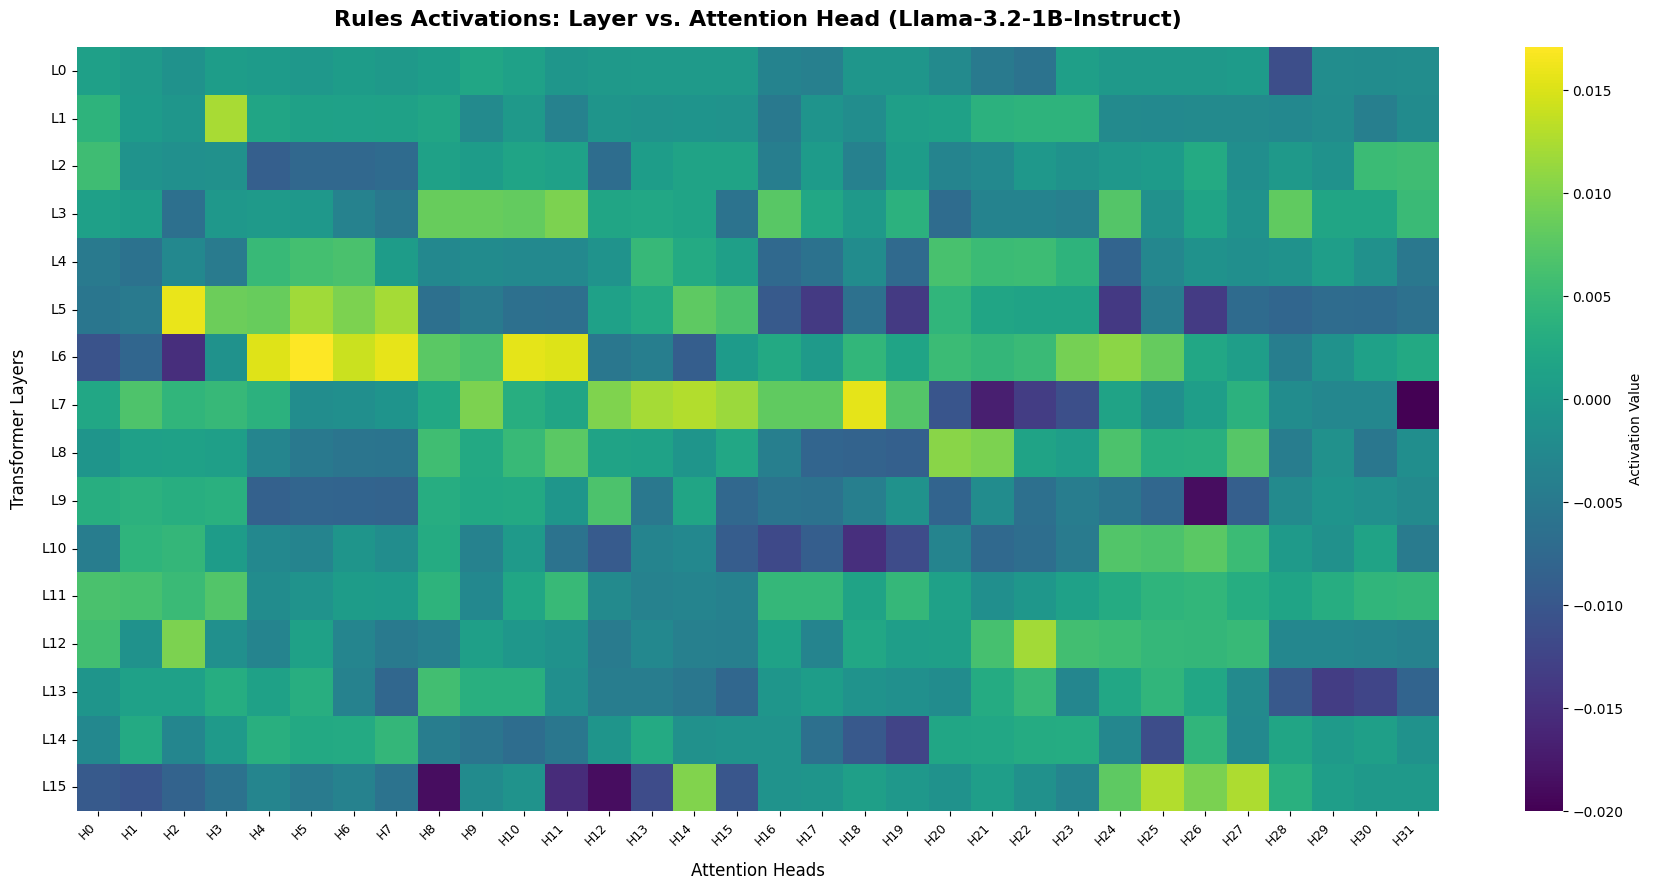

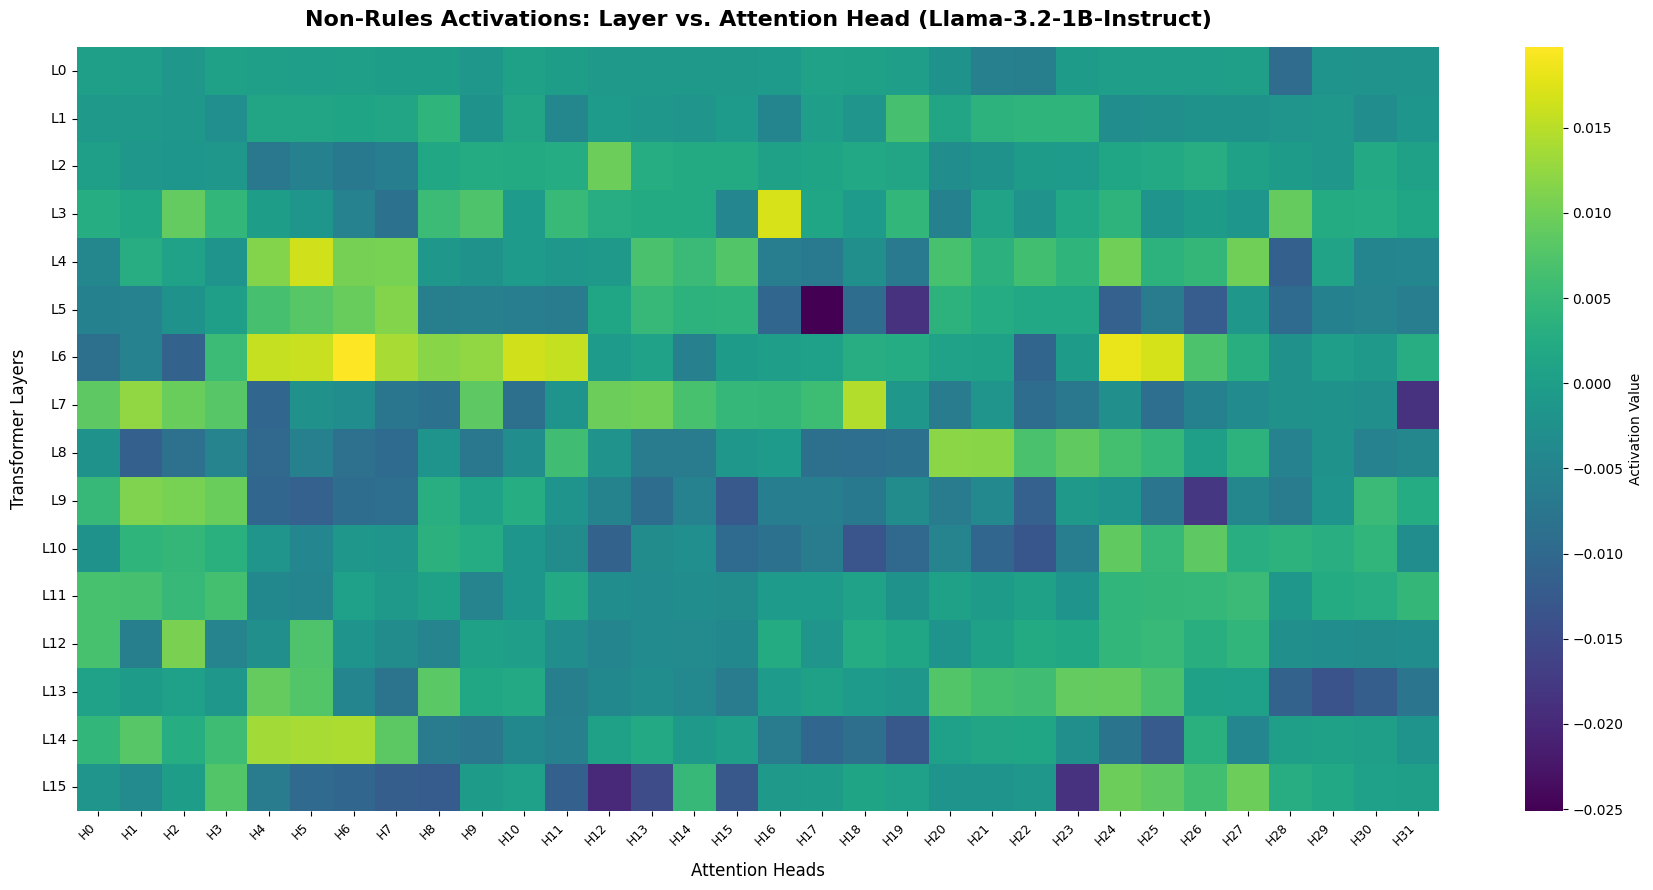

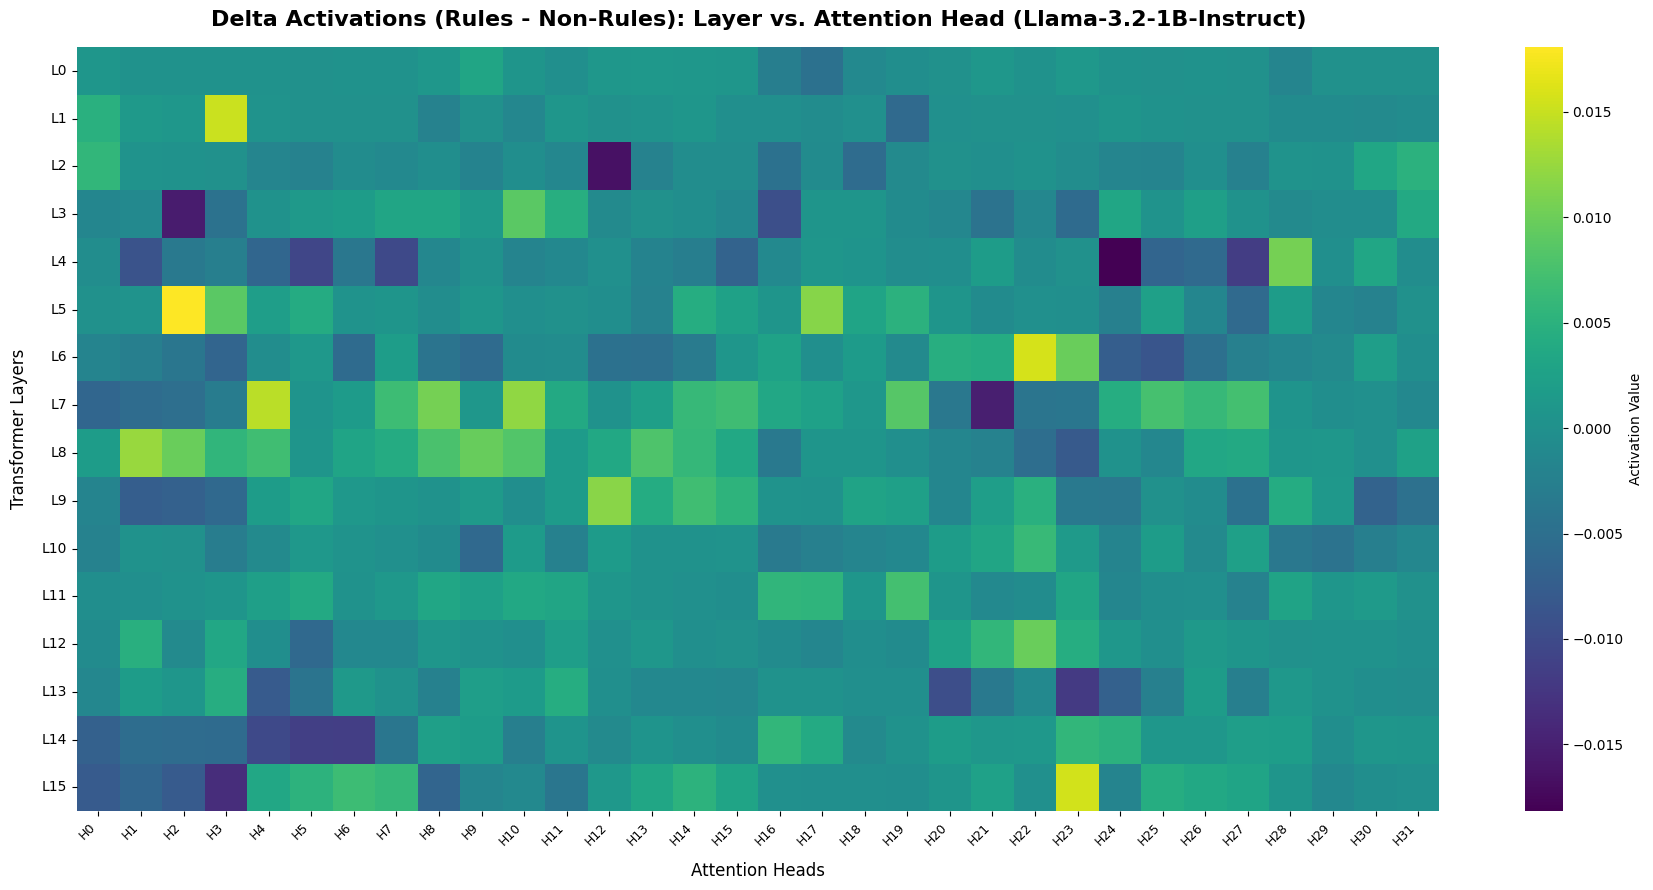

In [ ]:
plot_activation_heatmap(
    rules_acts_heads,
    "Rules Activations: Layer vs. Attention Head (Llama-3.2-1B-Instruct)",
    "Attention Heads",
    "Transformer Layers"
)

plot_activation_heatmap(
    non_rules_acts_heads,
    "Non-Rules Activations: Layer vs. Attention Head (Llama-3.2-1B-Instruct)",
    "Attention Heads",
    "Transformer Layers"
)

plot_activation_heatmap(
    deltas_heads,
    "Delta Activations (Rules - Non-Rules): Layer vs. Attention Head (Llama-3.2-1B-Instruct)",
    "Attention Heads",
    "Transformer Layers"
)

In [ ]:
mean_rules_per_layer = rules_acts_heads.mean(dim=1).cpu().numpy()
mean_non_rules_per_layer = non_rules_acts_heads.mean(dim=1).cpu().numpy()
for r, nr in zip(mean_rules_per_layer, mean_non_rules_per_layer):
    print('Rule', r, 'Non_rule', nr)
    print('-----------')

Rule -0.001065 Non_rule -0.001145
-----------
Rule -3.785e-05 Non_rule -0.0004103
-----------
Rule -0.001036 Non_rule -4.05e-06
-----------
Rule 0.001216 Non_rule 0.0016775
-----------
Rule -0.0008097 Non_rule 0.002043
-----------
Rule -0.001611 Non_rule -0.00314
-----------
Rule 0.003336 Non_rule 0.00423
-----------
Rule 0.00139 Non_rule -0.0004342
-----------
Rule 0.0002768 Non_rule -0.002335
-----------
Rule -0.003214 Non_rule -0.00345
-----------
Rule -0.002571 Non_rule -0.002058
-----------
Rule 0.001912 Non_rule 0.000597
-----------
Rule 0.0004997 Non_rule -0.0002072
-----------
Rule -0.001594 Non_rule -0.0003293
-----------
Rule -0.001368 Non_rule -0.0004249
-----------
Rule -0.00246 Non_rule -0.00277
-----------


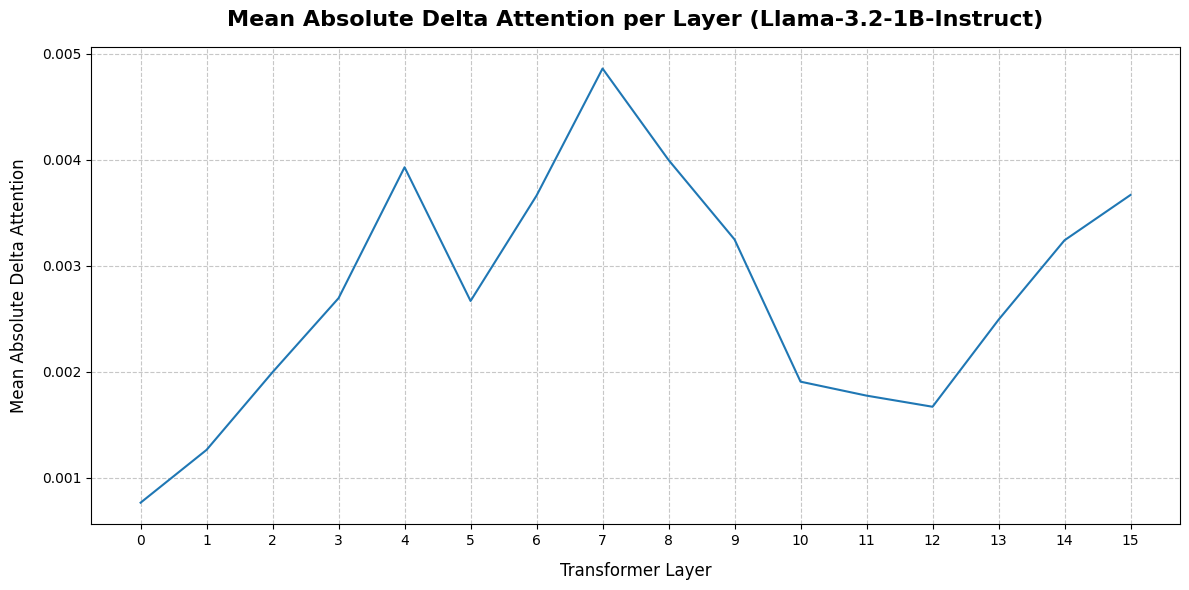

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean absolute delta attention per layer
mean_abs_deltas_per_layer = deltas_heads.abs().mean(dim=1).cpu().numpy()

# Create a DataFrame for plotting (optional, but good for seaborn)
import pandas as pd
plot_df = pd.DataFrame({
    'Layer': range(len(mean_abs_deltas_per_layer)),
    'Mean Absolute Delta Attention': mean_abs_deltas_per_layer
})

plt.figure(figsize=(12, 6))
sns.lineplot(x='Layer', y='Mean Absolute Delta Attention', data=plot_df)
plt.title('Mean Absolute Delta Attention per Layer (Llama-3.2-1B-Instruct)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Transformer Layer', fontsize=12, labelpad=10)
plt.ylabel('Mean Absolute Delta Attention', fontsize=12, labelpad=10)
plt.xticks(range(len(mean_abs_deltas_per_layer))) # Ensure all layers are visible on x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Pair layers with their mean absolute delta values
layer_deltas = list(enumerate(mean_abs_deltas_per_layer))

# Sort in descending order based on the delta value
sorted_layer_deltas = sorted(layer_deltas, key=lambda item: item[1], reverse=True)

print("Layers sorted by Mean Absolute Delta Attention (highest to lowest):")
for layer_idx, delta_value in sorted_layer_deltas:
    print(f"Layer {layer_idx}: {delta_value:.6f}")

Layers sorted by Mean Absolute Delta Attention (highest to lowest):
Layer 7: 0.004860
Layer 8: 0.003998
Layer 4: 0.003929
Layer 15: 0.003668
Layer 6: 0.003662
Layer 9: 0.003248
Layer 14: 0.003241
Layer 3: 0.002695
Layer 5: 0.002668
Layer 13: 0.002491
Layer 2: 0.001997
Layer 10: 0.001907
Layer 11: 0.001776
Layer 12: 0.001671
Layer 1: 0.001265
Layer 0: 0.000766


In [ ]:
min_abs_deltas_per_layer = deltas_heads.abs().min(dim=1).values.cpu().numpy()

# Pair layers with their min absolute delta values
layer_min_deltas = list(enumerate(min_abs_deltas_per_layer))

# Sort in descending order based on the delta value
sorted_layer_min_deltas = sorted(layer_min_deltas, key=lambda item: item[1], reverse=True)

print("Layers sorted by MIN Absolute Delta Attention (highest to lowest):")
for layer_idx, delta_value in sorted_layer_min_deltas:
    print(f"Layer {layer_idx}: {delta_value:.6f}")

Layers sorted by MIN Absolute Delta Attention (highest to lowest):
Layer 14: 0.000313
Layer 6: 0.000240
Layer 13: 0.000173
Layer 8: 0.000092
Layer 15: 0.000080
Layer 4: 0.000076
Layer 7: 0.000071
Layer 2: 0.000063
Layer 9: 0.000046
Layer 5: 0.000031
Layer 12: 0.000031
Layer 11: 0.000027
Layer 3: 0.000015
Layer 1: 0.000013
Layer 10: 0.000011
Layer 0: 0.000002


In [ ]:
max_abs_deltas_per_layer = deltas_heads.abs().max(dim=1).values.cpu().numpy()

# Pair layers with their max absolute delta values
layer_max_deltas = list(enumerate(max_abs_deltas_per_layer))

# Sort in descending order based on the delta value
sorted_layer_max_deltas = sorted(layer_max_deltas, key=lambda item: item[1], reverse=True)

print("Layers sorted by MAX Absolute Delta Attention (highest to lowest):")
for layer_idx, delta_value in sorted_layer_max_deltas:
    print(f"Layer {layer_idx}: {delta_value:.6f}")

Layers sorted by MAX Absolute Delta Attention (highest to lowest):
Layer 4: 0.018173
Layer 5: 0.018082
Layer 2: 0.016556
Layer 6: 0.015762
Layer 15: 0.015541
Layer 3: 0.015442
Layer 1: 0.015221
Layer 7: 0.015182
Layer 8: 0.012428
Layer 13: 0.012016
Layer 9: 0.011604
Layer 14: 0.011604
Layer 12: 0.009766
Layer 11: 0.007191
Layer 10: 0.006294
Layer 0: 0.004620


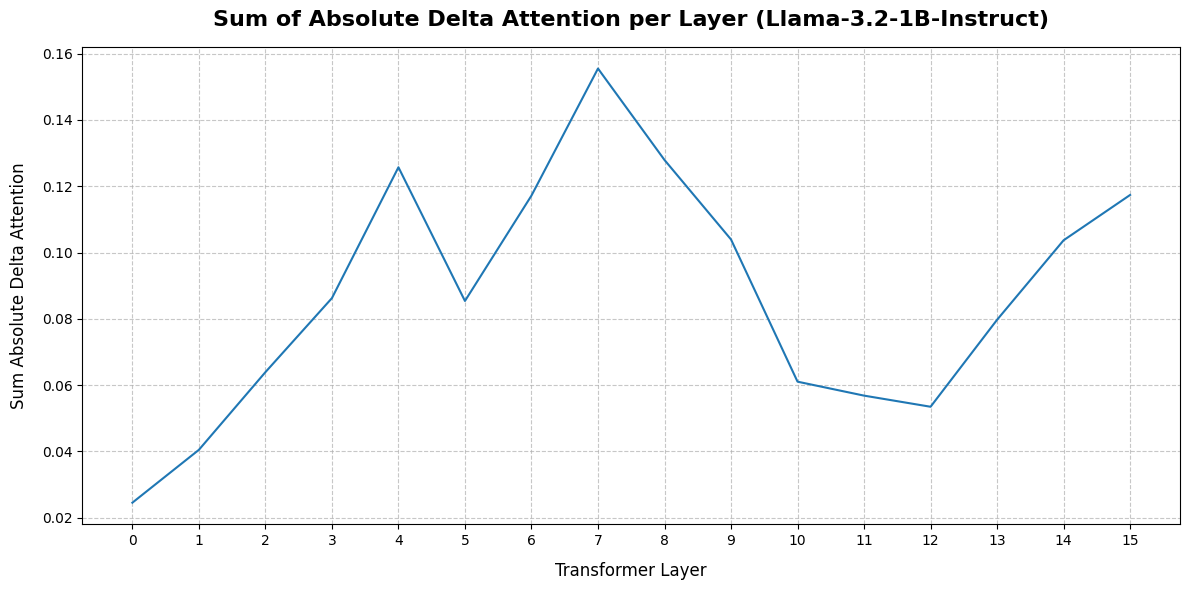

In [ ]:
# Calculate sum of absolute delta attention per layer
sum_abs_deltas_per_layer = deltas_heads.abs().sum(dim=1).cpu().numpy()

# Create a DataFrame for plotting
plot_df_sum = pd.DataFrame({
    'Layer': range(len(sum_abs_deltas_per_layer)),
    'Sum Absolute Delta Attention': sum_abs_deltas_per_layer
})

plt.figure(figsize=(12, 6))
sns.lineplot(x='Layer', y='Sum Absolute Delta Attention', data=plot_df_sum)
plt.title('Sum of Absolute Delta Attention per Layer (Llama-3.2-1B-Instruct)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Transformer Layer', fontsize=12, labelpad=10)
plt.ylabel('Sum Absolute Delta Attention', fontsize=12, labelpad=10)
plt.xticks(range(len(sum_abs_deltas_per_layer))) # Ensure all layers are visible on x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Logit Lens

In [ ]:
def perform_logit_lens(
    text_string: str,
    model: HookedTransformer,
    hook_point: str = "hook_resid_post", # New parameter
    scalar: float = 1.0,                 # New parameter
    num_top_tokens: int = 20
) -> dict:
    """
    Performs a logit lens on a given text string for all layers of the model,
    using a specified hook point and an optional scalar.

    Args:
        text_string: The input text to analyze.
        model: The HookedTransformer model.
        hook_point: The name of the hook point to extract activations from (e.g., "hook_resid_post", "attn.hook_result", "mlp.hook_post").
                    The output of this hook point should be a d_model vector.
        scalar: A scalar value to multiply the extracted activation vector by. Defaults to 1.0.
        num_top_tokens: The number of top tokens to return for each layer.

    Returns:
        A dictionary {layer_num: [list of (token_str, logit_value)]}
    """
    tokens = model.to_tokens(text_string, prepend_bos=True).to(model.cfg.device)

    # We need the residual stream after each block (hook_resid_post) or other specified hook
    # The names_filter should be specific enough to capture the hook_point within each block.
    names_filter = lambda name: name.endswith(f".{hook_point}")

    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=names_filter)

    logit_lens_results = {}
    for layer_idx in range(model.cfg.n_layers):
        hook_full_name = f"blocks.{layer_idx}.{hook_point}"
        if hook_full_name not in cache:
            # This can happen if a specific hook_point does not exist for a given layer,
            # or if the names_filter was too restrictive/permissive. For d_model outputs,
            # these should generally exist per layer.
            continue

        # Get the activation vector for the last token of the current layer from the specified hook_point
        # The cache entry will have shape (batch, seq_len, d_model) for appropriate hook_points
        activation_vector_at_layer = cache[hook_full_name][0, -1, :]

        # Apply the final layernorm (RMSNorm for Llama) if the model has one
        if hasattr(model, 'ln_final') and model.ln_final is not None:
            normalized_activation = model.ln_final(activation_vector_at_layer)
        else:
            normalized_activation = activation_vector_at_layer

        # Apply scalar AFTER normalization
        scaled_normalized_activation = normalized_activation * scalar

        # Apply the unembedding matrix and bias to get logits using model.unembed
        layer_logits = model.unembed(scaled_normalized_activation)

        # Get top tokens and their logit values
        top_k_values, top_k_indices = torch.topk(layer_logits, num_top_tokens)

        tokens_info = []
        for val, idx in zip(top_k_values, top_k_indices):
            token_str = model.to_string(idx.item())
            tokens_info.append((token_str, val.item()))

        logit_lens_results[layer_idx] = tokens_info

    return logit_lens_results

In [ ]:
def perform_delta_logit_lens(
    rule_text: str,
    non_rule_text: str,
    model: HookedTransformer,
    scalar: float = 1.0,
    num_top_tokens: int = 20
) -> dict:
    """
    Calculates the difference (delta) in `hook_resid_post` activations between
    a rule text and a non-rule text, then normalizes, scales, and applies a
    logit lens to this delta for each layer.

    Args:
        rule_text: The input rule text string.
        non_rule_text: The input non-rule text string.
        model: The HookedTransformer model.
        scalar: A scalar value to multiply the normalized delta vector by. Defaults to 1.0.
        num_top_tokens: The number of top tokens to return for each layer.

    Returns:
        A dictionary {layer_num: [list of (token_str, logit_value)]}
    """
    hook_point = "hook_resid_post"

    # Get residual stream activations for the rule text
    rule_tokens = model.to_tokens(rule_text, prepend_bos=True).to(model.cfg.device)
    _, rule_cache = model.run_with_cache(
        rule_tokens,
        names_filter=lambda name: name.endswith(f".{hook_point}")
    )

    # Get residual stream activations for the non-rule text
    non_rule_tokens = model.to_tokens(non_rule_text, prepend_bos=True).to(model.cfg.device)
    _, non_rule_cache = model.run_with_cache(
        non_rule_tokens,
        names_filter=lambda name: name.endswith(f".{hook_point}")
    )

    delta_logit_lens_results = {}
    for layer_idx in range(model.cfg.n_layers):
        hook_full_name = f"blocks.{layer_idx}.{hook_point}"

        if hook_full_name not in rule_cache or hook_full_name not in non_rule_cache:
            continue

        # Get activation vectors for the last token of the current layer
        rule_activation_vector = rule_cache[hook_full_name][0, -1, :]
        non_rule_activation_vector = non_rule_cache[hook_full_name][0, -1, :]

        # Calculate the delta vector
        delta_activation_vector = rule_activation_vector - non_rule_activation_vector

        # Apply the final layernorm (RMSNorm for Llama) if the model has one
        if hasattr(model, 'ln_final') and model.ln_final is not None:
            normalized_delta = model.ln_final(delta_activation_vector)
        else:
            normalized_delta = delta_activation_vector

        # Apply scalar AFTER normalization
        scaled_normalized_delta = normalized_delta * scalar

        # Apply the unembedding matrix and bias to get logits
        layer_logits = model.unembed(scaled_normalized_delta)

        # Get top tokens and their logit values
        top_k_values, top_k_indices = torch.topk(layer_logits, num_top_tokens)

        tokens_info = []
        for val, idx in zip(top_k_values, top_k_indices):
            token_str = model.to_string(idx.item())
            tokens_info.append((token_str, val.item()))

        delta_logit_lens_results[layer_idx] = tokens_info

    return delta_logit_lens_results

In [ ]:
import random

# Randomly pick 4 pairs from each group of contrastive_dataset
group_size = 30
num_groups = 4 # There are 4 groups of 30 in contrastive_dataset
sampled_pairs = [] # Store (rule_prompt, non_rule_prompt) tuples

for i in range(num_groups):
    start_idx = i * group_size
    end_idx = start_idx + group_size
    current_group = contrastive_dataset[start_idx:end_idx]

    # Randomly sample 4 pairs. random.sample works without replacement.
    for rule_prompt, non_rule_prompt in random.sample(current_group, k=4):
        sampled_pairs.append((rule_prompt, non_rule_prompt))

In [ ]:
logit_lens_outputs = {}
for i, (original_rule_prompt, original_non_rule_prompt) in enumerate(sampled_pairs):
    # Prepend context ONLY to the rule prompt
    augmented_rule_prompt = "The weather is nice today. " + original_rule_prompt

    print(f"  Rule: '{augmented_rule_prompt}'")
    print(f"  Non-Rule: '{original_non_rule_prompt}'")

    try:
        rule_result = perform_logit_lens(augmented_rule_prompt, model)
        non_rule_result = perform_logit_lens(original_non_rule_prompt, model)

        logit_lens_outputs[original_rule_prompt] = {
            'augmented_rule_prompt': augmented_rule_prompt,
            'non_rule_prompt': original_non_rule_prompt,
            'augmented_rule_result': rule_result,
            'non_rule_result': non_rule_result
        }

        for layer_idx in range(model.cfg.n_layers):
            print(f"Layer {layer_idx}:")
            # Print headers for side-by-side
            print(f"{'  --- RULE LOGITS (Top 5) ---':<50}|{'--- NON-RULE LOGITS (Top 5) ---'}")
            print(f"{'  ------------------------------------------------':<50}|{'------------------------------------------------'}")

            for k in range(5):
                rule_token, rule_logit = rule_result[layer_idx][k]
                non_rule_token, non_rule_logit = non_rule_result[layer_idx][k]

                # Format each side
                rule_output_str = f"    Token: {rule_token}, Logit: {rule_logit:.2f}"
                non_rule_output_str = f"    Token: {non_rule_token}, Logit: {non_rule_logit:.2f}"

                # Print side-by-side, padding to ensure alignment
                print(f"{rule_output_str:<50}|{non_rule_output_str}")
            print('----------------------------------------------------------------------------------------------------')

    except Exception as e:
        print(f"Error processing pair ('{augmented_rule_prompt}', '{original_non_rule_prompt}'): {e}")
    print('#######################')

  Rule: 'The weather is nice today. Write a Python function.'
  Non-Rule: 'This is a Python function.'
Layer 0:
  --- RULE LOGITS (Top 5) ---                     |--- NON-RULE LOGITS (Top 5) ---
  ------------------------------------------------|------------------------------------------------
    Token: ., Logit: 19.11                        |    Token: ., Logit: 21.94
    Token:  ., Logit: 9.59                        |    Token:  ., Logit: 11.21
    Token: .
, Logit: 9.17                        |    Token: .
, Logit: 11.06
    Token: .

, Logit: 7.77                       |    Token: .

, Logit: 10.13
    Token:  , Logit: 7.21                         |    Token: ।, Logit: 7.34
----------------------------------------------------------------------------------------------------
Layer 1:
  --- RULE LOGITS (Top 5) ---                     |--- NON-RULE LOGITS (Top 5) ---
  ------------------------------------------------|------------------------------------------------
    Token: ., Logit

There are quite a few interesting differences between the logit lens on rules and non-rules. Starting from layers 4-7 rules seem to prioritise imperative words, e.g. *write* in *Write in a polite tone*, while similar non-rule *Written in a polite tone* prioritises smth like *info, tone* etc.

## Logit Lens on Attn and Delta Vectors

In [ ]:
attn_logit_lens_outputs = {}
for i, (original_rule_prompt, original_non_rule_prompt) in enumerate(sampled_pairs):
    # Prepend context ONLY to the rule prompt
    augmented_rule_prompt = "The weather is nice today. " + original_rule_prompt

    print(f"  Rule: '{augmented_rule_prompt}'")
    print(f"  Non-Rule: '{original_non_rule_prompt}'")

    try:
        attn_rule_result = perform_logit_lens(
            augmented_rule_prompt,
            model,
            hook_point=hook_attn,
            scalar=1.0,
        )
        attn_non_rule_result = perform_logit_lens(
            original_non_rule_prompt,
            model,
            hook_point=hook_attn,
            scalar=1.0,
        )

        attn_logit_lens_outputs[original_rule_prompt] = {
            'augmented_rule_prompt': augmented_rule_prompt,
            'non_rule_prompt': original_non_rule_prompt,
            'augmented_rule_result': attn_rule_result,
            'non_rule_result': attn_non_rule_result
        }

        for layer_idx in range(model.cfg.n_layers):
            print(f"Layer {layer_idx}:")
            # Print headers for side-by-side
            print(f"{'  --- RULE LOGITS (Top 5) ---':<50}|{'--- NON-RULE LOGITS (Top 5) ---'}")
            print(f"{'  ------------------------------------------------':<50}|{'------------------------------------------------'}")

            for k in range(5):
                attn_rule_token, attn_rule_logit = attn_rule_result[layer_idx][k]
                attn_non_rule_token, attn_non_rule_logit = attn_non_rule_result[layer_idx][k]

                # Format each side
                rule_output_str = f"    Token: {attn_rule_token}, Logit: {attn_rule_logit:.2f}"
                non_rule_output_str = f"    Token: {attn_non_rule_token}, Logit: {attn_non_rule_logit:.2f}"

                # Print side-by-side, padding to ensure alignment
                print(f"{rule_output_str:<50}|{non_rule_output_str}")
            print('----------------------------------------------------------------------------------------------------')

    except Exception as e:
        print(f"Error processing pair ('{augmented_rule_prompt}', '{original_non_rule_prompt}'): {e}")
    print('#######################')

  Rule: 'The weather is nice today. Write a Python function.'
  Non-Rule: 'This is a Python function.'
Layer 0:
  --- RULE LOGITS (Top 5) ---                     |--- NON-RULE LOGITS (Top 5) ---
  ------------------------------------------------|------------------------------------------------
    Token: tainment, Logit: 21.86                 |    Token: .dds, Logit: 19.81
    Token: inize, Logit: 20.89                    |    Token:  '::, Logit: 19.02
    Token: #ac, Logit: 20.83                      |    Token: #ac, Logit: 18.98
    Token: .dds, Logit: 20.61                     |    Token: -stack, Logit: 18.91
    Token: iê, Logit: 20.47                       |    Token:  |:, Logit: 18.86
----------------------------------------------------------------------------------------------------
Layer 1:
  --- RULE LOGITS (Top 5) ---                     |--- NON-RULE LOGITS (Top 5) ---
  ------------------------------------------------|------------------------------------------------
    Tok

Hard to say if there is anything meaningful in logit lens for delta vectors.

In [ ]:
mlp_logit_lens_outputs = {}
for i, (original_rule_prompt, original_non_rule_prompt) in enumerate(sampled_pairs):
    # Prepend context ONLY to the rule prompt
    augmented_rule_prompt = "The weather is nice today. " + original_rule_prompt

    print(f"  Rule: '{augmented_rule_prompt}'")
    print(f"  Non-Rule: '{original_non_rule_prompt}'")

    try:
        mlp_rule_result = perform_logit_lens(
            augmented_rule_prompt,
            model,
            hook_point=hook_mlp,
            scalar=1.0,
        )
        mlp_non_rule_result = perform_logit_lens(
            original_non_rule_prompt,
            model,
            hook_point=hook_mlp,
            scalar=1.0,
        )

        mlp_logit_lens_outputs[original_rule_prompt] = {
            'augmented_rule_prompt': augmented_rule_prompt,
            'non_rule_prompt': original_non_rule_prompt,
            'augmented_rule_result': mlp_rule_result,
            'non_rule_result': mlp_non_rule_result
        }

        for layer_idx in range(model.cfg.n_layers):
            print(f"Layer {layer_idx}:")
            # Print headers for side-by-side
            print(f"{'  --- RULE LOGITS (Top 5) ---':<50}|{'--- NON-RULE LOGITS (Top 5) ---'}")
            print(f"{'  ------------------------------------------------':<50}|{'------------------------------------------------'}")

            for k in range(5):
                mlp_rule_token, mlp_rule_logit = mlp_rule_result[layer_idx][k]
                mlp_non_rule_token, mlp_non_rule_logit = mlp_non_rule_result[layer_idx][k]

                # Format each side
                rule_output_str = f"    Token: {mlp_rule_token}, Logit: {mlp_rule_logit:.2f}"
                non_rule_output_str = f"    Token: {mlp_non_rule_token}, Logit: {mlp_non_rule_logit:.2f}"

                # Print side-by-side, padding to ensure alignment
                print(f"{rule_output_str:<50}|{non_rule_output_str}")
            print('----------------------------------------------------------------------------------------------------')

    except Exception as e:
        print(f"Error processing pair ('{augmented_rule_prompt}', '{original_non_rule_prompt}'): {e}")
    print('#######################')

  Rule: 'The weather is nice today. Write a Python function.'
  Non-Rule: 'This is a Python function.'
Layer 0:
  --- RULE LOGITS (Top 5) ---                     |--- NON-RULE LOGITS (Top 5) ---
  ------------------------------------------------|------------------------------------------------
    Token: ropri, Logit: 11.52                    |    Token: :"., Logit: 14.98
    Token: ære, Logit: 11.31                      |    Token: ).', Logit: 14.77
    Token: ELY, Logit: 11.31                      |    Token: :host, Logit: 14.46
    Token: ")(, Logit: 11.26                      |    Token: ’.

, Logit: 14.45
    Token: .appspot, Logit: 11.13                 |    Token: ropri, Logit: 14.43
----------------------------------------------------------------------------------------------------
Layer 1:
  --- RULE LOGITS (Top 5) ---                     |--- NON-RULE LOGITS (Top 5) ---
  ------------------------------------------------|------------------------------------------------
    Tok

MLPs and Attn logit lens are not informative at all, just look like noise. Thats why Direct Logit Lens exists.

In [ ]:
rule_text = 'The weather is nice today. Please, write in a formal tone.'
non_rule_text = 'The weather is nice today. This is written in a formal tone.'

delta_logit_result = perform_delta_logit_lens(
    rule_text,
    non_rule_text,
    model,
    scalar=90.0,
    num_top_tokens=20
)
for layer, tokens_info in delta_logit_result.items():
    print(f"Layer {layer}:")
    for token, score in tokens_info:
        print(token, score, end=' | ')
        print('----------------------------------')
    print('##############################')

Layer 0:
 cour 606.0 | ----------------------------------
zers 595.0 | ----------------------------------
elmet 589.0 | ----------------------------------
aims 579.0 | ----------------------------------
eldorf 556.0 | ----------------------------------
ecz 552.0 | ----------------------------------
 guessing 550.5 | ----------------------------------
ành 550.0 | ----------------------------------
 cou 546.5 | ----------------------------------
 rooted 542.5 | ----------------------------------
tlement 542.0 | ----------------------------------
 nto 534.0 | ----------------------------------
assing 533.0 | ----------------------------------
gee 525.5 | ----------------------------------
 Aires 522.5 | ----------------------------------
ITED 522.5 | ----------------------------------
gra 513.0 | ----------------------------------
mp 512.5 | ----------------------------------
kits 511.75 | ----------------------------------
ledo 507.75 | ----------------------------------
################

Overall, logit lens for smth other than resid_post is not very informative.